In [1]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv(
    "Ventas_modulo41.csv",
    sep=";",
    encoding="utf-8-sig"
)

2. Comparar vendedores

In [2]:
print(df.columns.tolist())
print(df["Vendedor"].unique())
print(df["Vendedor"].value_counts(dropna=False))

['Ciudad', 'Lugar', 'Cliente', 'Vendedor', 'Territorio', 'Socio', 'Ventas', 'Cantidad', 'Producto', 'Fecha', 'Precio_Unitario', 'Nivel_Venta']
<ArrowStringArray>
['Jose', 'Victor', 'Edwin', 'Nadia', 'Marco', 'Maria', 'Rosa', 'Nora',
 'Javier']
Length: 9, dtype: str
Vendedor
Victor    254
Nora      172
Jose       93
Edwin      93
Marco      93
Nadia      83
Maria      80
Rosa       80
Javier     26
Name: count, dtype: int64


In [3]:
from scipy import stats

grupo_a = df.loc[
    df["Vendedor"] == "Victor",
    "Ventas"
].dropna()

grupo_b = df.loc[
    df["Vendedor"] == "Nora",
    "Ventas"
].dropna()

if len(grupo_a) < 2 or len(grupo_b) < 2:
    print("No hay suficientes datos para realizar el t-test.")
    print(f"{"Victor"}: {len(grupo_a)} observaciones")
    print(f"{"Nora"}: {len(grupo_b)} observaciones")
else:
    resultado = stats.ttest_ind(
        grupo_a,
        grupo_b,
        equal_var=False,
        nan_policy="omit"
    )

    print("Estadístico:", resultado.statistic)
    print("Valor p:", resultado.pvalue)

Estadístico: 0.7661977450515574
Valor p: 0.4440345923150502


0.4440 > 0.05
no se rechaza la hipótesis nula. Por tanto, con los datos disponibles, no existe evidencia estadística suficiente para afirmar que las ventas medias de ambos empleados sean diferentes

t = 0.7662
indica que el primer empleado de tu comparación tiene una media de ventas superior al segundo

In [4]:
print("Empleado A:", "Victor")
print("Observaciones:", len(grupo_a))
print("Media:", grupo_a.mean())
print("Mediana:", grupo_a.median())
print("Desviación típica:", grupo_a.std())

print("\nEmpleado B:", "Nora")
print("Observaciones:", len(grupo_b))
print("Media:", grupo_b.mean())
print("Mediana:", grupo_b.median())
print("Desviación típica:", grupo_b.std())

Empleado A: Victor
Observaciones: 254
Media: 152603.61023622047
Mediana: 150940.0
Desviación típica: 58452.745509771325

Empleado B: Nora
Observaciones: 172
Media: 148314.86627906977
Mediana: 147298.5
Desviación típica: 55455.36849221854


In [5]:
diferencia = grupo_a.mean() - grupo_b.mean()

print("Diferencia de medias:", diferencia)

Diferencia de medias: 4288.743957150698


Víctor obtuvo una venta media de 152.603,61, frente a 148.314,87 de Nora. Aunque Víctor presenta una diferencia favorable de 4.288,74, la prueba t de Welch no detectó una diferencia estadísticamente significativa entre ambos empleados 
(t=0.7662, p=0.4440). Por tanto, con estos datos no puede afirmarse que Víctor tenga un rendimiento medio de ventas superior al de Nora.

 sección 3: relación entre ventas y cantidad

In [6]:
datos = df[[
    "Cantidad",
    "Ventas"
]].dropna()

correlacion_pearson = stats.pearsonr(
    datos["Cantidad"],
    datos["Ventas"]
)

correlacion_spearman = stats.spearmanr(
    datos["Cantidad"],
    datos["Ventas"]
)

print("Pearson:", correlacion_pearson)
print("Spearman:", correlacion_spearman)

Pearson: PearsonRResult(statistic=np.float64(0.003192782473025856), pvalue=np.float64(0.9207287744772692))
Spearman: SignificanceResult(statistic=np.float64(0.0027378875002514), pvalue=np.float64(0.9319934031859891))


0.9207 > 0.05
0.9320 > 0.05

Por tanto, no se rechaza la hipótesis nula de ausencia de correlación. No hay evidencia estadística suficiente para afirmar que exista una relación entre cantidad y ventas.

In [7]:
df["PrecioUnitario"] = (
    df["Ventas"] /
    df["Cantidad"].replace(0, np.nan)
)

In [8]:
datos_precio = df[[
    "Cantidad",
    "PrecioUnitario"
]].dropna()

resultado_precio = stats.spearmanr(
    datos_precio["Cantidad"],
    datos_precio["PrecioUnitario"]
)

print("Spearman cantidad-precio:")
print("Estadístico:", resultado_precio.statistic)
print("Valor p:", resultado_precio.pvalue)

Spearman cantidad-precio:
Estadístico: -0.5547036785838972
Valor p: 1.114677399293386e-79


p < 0.05

se rechaza la hipótesis nula de ausencia de relación. Existe evidencia estadística muy fuerte de asociación entre cantidad y precio unitario.

Posible interpretación comercial
El resultado puede indicar que:
se aplican descuentos por volumen;
los pedidos grandes tienen un precio unitario menor;
los productos baratos se venden en mayores cantidades;
los productos caros se venden en cantidades pequeñas;
existen diferencias importantes de precio entre productos.

Sin embargo, no podemos afirmar todavía que vender más unidades provoque una reducción del precio. La correlación no demuestra causalidad.

In [9]:
resultados_producto = []

for producto, grupo in df.groupby("Producto"):
    grupo = grupo[
        ["Cantidad", "PrecioUnitario"]
    ].dropna()

    if len(grupo) >= 10:
        resultado = stats.spearmanr(
            grupo["Cantidad"],
            grupo["PrecioUnitario"]
        )

        resultados_producto.append({
            "Producto": producto,
            "Observaciones": len(grupo),
            "Spearman": resultado.statistic,
            "Valor_p": resultado.pvalue
        })

correlaciones_producto = pd.DataFrame(
    resultados_producto
)

correlaciones_producto.sort_values(
    "Spearman"
)

,Producto,Observaciones,Spearman,Valor_p
2,Electrodomesticos,200,-0.604201,2.746803e-21
3,Juguetes,244,-0.571929,1.350405e-22
0,Accesorios,370,-0.559939,6.399821e-32
4,Viajes,75,-0.558412,1.931466e-07
1,Calzado,85,-0.388614,2.375097e-04


El análisis por producto muestra una correlación de Spearman negativa y significativa entre cantidad y precio unitario en todas las categorías analizadas. Esto sugiere que, dentro de cada producto, los pedidos de mayor volumen tienden a registrarse con un precio unitario menor, lo que es compatible con una política de descuentos por cantidad o con diferencias comerciales según el tamaño del pedido.

Los resultados indican que, dentro de cada producto, las operaciones con mayor cantidad vendida tienden a registrar un precio unitario menor. La relación es más intensa en Electrodomésticos, con ρ=−0,6042, y más débil en Calzado, con ρ=−0,3886.

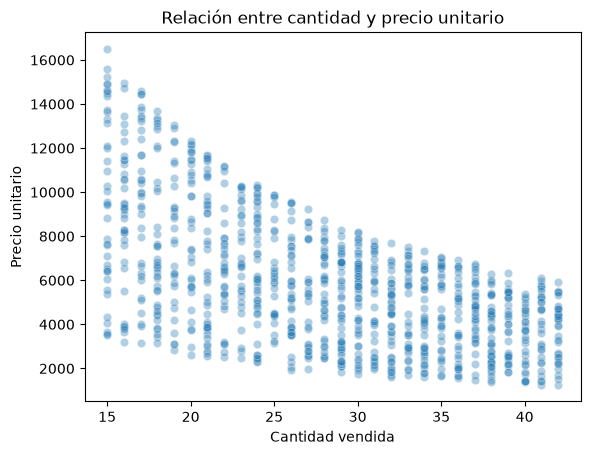

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df.sample(
        min(5000, len(df)),
        random_state=42
    ),
    x="Cantidad",
    y="PrecioUnitario",
    alpha=0.35
)

plt.title(
    "Relación entre cantidad y precio unitario"
)
plt.xlabel("Cantidad vendida")
plt.ylabel("Precio unitario")
plt.show()

La gráfica confirma visualmente este comportamiento: los puntos forman una tendencia descendente, especialmente cuando la cantidad aumenta.

Este patrón podría estar relacionado con:

descuentos por volumen;

negociación de precios en pedidos grandes;

promociones aplicadas a determinadas cantidades;

diferencias entre clientes o tipos de operación.

<Axes: xlabel='Cantidad', ylabel='PrecioUnitario'>

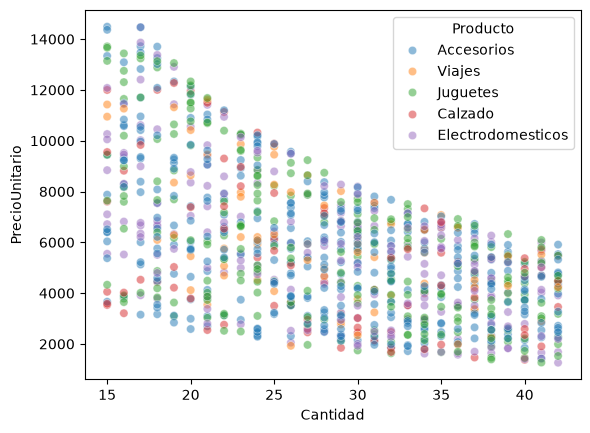

In [11]:
limite_cantidad = df["Cantidad"].quantile(0.99)
limite_precio = df["PrecioUnitario"].quantile(0.99)

grafico = df[
    (df["Cantidad"] <= limite_cantidad) &
    (df["PrecioUnitario"] <= limite_precio)
]

sns.scatterplot(
    data=grafico,
    x="Cantidad",
    y="PrecioUnitario",
    hue="Producto",
    alpha=0.5
)

El análisis de Spearman muestra una relación negativa y estadísticamente significativa entre la cantidad vendida y el precio unitario en todos los productos estudiados. Esto sugiere que los pedidos de mayor volumen tienden a obtener un precio unitario más bajo. La relación es moderada en todas las categorías, siendo más fuerte en Electrodomésticos y más débil en Calzado. No obstante, la correlación no demuestra por sí sola que el aumento de la cantidad provoque una reducción del precio; para confirmar la existencia de descuentos por volumen sería necesario analizar también el cliente, el territorio, el vendedor y las condiciones comerciales.

Una vez analizada la relación entre cantidad y precio unitario, el siguiente paso será detectar valores atípicos en las variables Ventas y PrecioUnitario, con el fin de identificar operaciones extraordinarias, posibles errores de registro o transacciones que puedan influir excesivamente en los resultados.

4. Detección de valores atípicos
El objetivo es identificar operaciones con valores inusualmente altos o bajos que puedan representar:

ventas extraordinarias;

pedidos con muchas unidades;

precios unitarios especiales;

errores de registro;

operaciones que influyan demasiado en las medias y correlaciones.

In [12]:
q1_ventas = df["Ventas"].quantile(0.25)
q3_ventas = df["Ventas"].quantile(0.75)

iqr_ventas = q3_ventas - q1_ventas

limite_inferior_ventas = q1_ventas - 1.5 * iqr_ventas
limite_superior_ventas = q3_ventas + 1.5 * iqr_ventas

ventas_atipicas = df[
    (df["Ventas"] < limite_inferior_ventas) |
    (df["Ventas"] > limite_superior_ventas)
].copy()

print("Q1:", q1_ventas)
print("Q3:", q3_ventas)
print("IQR:", iqr_ventas)
print("Límite inferior:", limite_inferior_ventas)
print("Límite superior:", limite_superior_ventas)
print("Valores atípicos:", len(ventas_atipicas))

Q1: 100321.0
Q3: 200224.75
IQR: 99903.75
Límite inferior: -49534.625
Límite superior: 350080.375
Valores atípicos: 0


Para detectar valores atípicos en la variable Ventas, se aplicó el método del rango intercuartílico. El primer cuartil fue de 100.321,00 y el tercer cuartil de 200.224,75, obteniéndose un IQR de 99.903,75. Los límites calculados fueron -49.534,625 y 350.080,375. No se detectaron observaciones fuera de estos límites, por lo que no existen valores atípicos en Ventas según el método IQR.

In [13]:
q1_precio = df["PrecioUnitario"].quantile(0.25)
q3_precio = df["PrecioUnitario"].quantile(0.75)

iqr_precio = q3_precio - q1_precio

limite_inferior_precio = q1_precio - 1.5 * iqr_precio
limite_superior_precio = q3_precio + 1.5 * iqr_precio

precios_atipicos = df[
    (df["PrecioUnitario"] < limite_inferior_precio) |
    (df["PrecioUnitario"] > limite_superior_precio)
]

print("Q1:", q1_precio)
print("Q3:", q3_precio)
print("IQR:", iqr_precio)
print("Límite inferior:", limite_inferior_precio)
print("Límite superior:", limite_superior_precio)
print("Valores atípicos:", len(precios_atipicos))

Q1: 3569.4193548387093
Q3: 7334.035243407708
IQR: 3764.6158885689983
Límite inferior: -2077.504478014788
Límite superior: 12980.959076261206
Valores atípicos: 31


Como el precio unitario no debería ser negativo, el límite inferior no tiene relevancia práctica. Por tanto, los 31 valores atípicos están por encima de 12.980,96.

El método IQR considera atípicos los valores que están fuera de los límites 𝑄1−1.5×𝐼𝑄𝑅.Esto significa que existen 31 operaciones con un precio unitario excepcionalmente alto respecto al comportamiento central de la base.

In [14]:
precios_atipicos = df[
    df["PrecioUnitario"] > limite_superior_precio
].copy()

precios_atipicos[[
    "Producto",
    "Cantidad",
    "Ventas",
    "PrecioUnitario",
    "Vendedor",
    "Territorio",
    "Cliente"
]].sort_values(
    "PrecioUnitario",
    ascending=False
)

,Producto,Cantidad,Ventas,PrecioUnitario,Vendedor,Territorio,Cliente
327,Accesorios,15,247691,16512.733333,Victor,Norte,Ferrocarriles Centrales
924,Calzado,15,234136,15609.066667,Edwin,Norte,Banco Interno
735,Juguetes,15,228631,15242.066667,Edwin,Norte,Grandes Montañas
412,Accesorios,16,239300,14956.250000,Victor,Norte,"Minsur, S.A."
820,Accesorios,15,223849,14923.266667,Edwin,Norte,Banco Interno
817,Accesorios,15,223804,14920.266667,Nora,Sur,"Diners Club Peru, S.A"
1,Viajes,16,235562,14722.625000,Victor,Norte,San Martin Inc
798,Juguetes,15,219452,14630.133333,Edwin,Sur,PANA AUTOS S.A.
105,Accesorios,15,219157,14610.466667,Jose,Sur,"Compañia Minera Poderosa, S.A."
534,Accesorios,17,248288,14605.176471,Marco,Sur,Tiendas Wang


In [15]:
atipicos_por_producto = (
    precios_atipicos
    .groupby("Producto")
    .size()
    .sort_values(ascending=False)
)

print(atipicos_por_producto)

Producto
Accesorios           16
Juguetes             10
Electrodomesticos     3
Calzado               1
Viajes                1
dtype: int64


Los 31 valores atípicos detectados en PrecioUnitario se concentran principalmente en los productos Accesorios y Juguetes, que representan el 83,87% del total de observaciones atípicas. Accesorios registra 16 casos y Juguetes 10, mientras que Electrodomésticos, Calzado y Viajes presentan una cantidad menor. Esta concentración puede deberse a diferencias en la distribución de precios, a una mayor variabilidad dentro de esos productos o a operaciones especiales. Por ello, estos registros deben revisarse antes de considerarlos errores o eliminarlos.

In [16]:
def detectar_atipicos(grupo):
    q1 = grupo["PrecioUnitario"].quantile(0.25)
    q3 = grupo["PrecioUnitario"].quantile(0.75)
    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    grupo = grupo.copy()
    grupo["Atipico"] = (
        grupo["PrecioUnitario"] > limite_superior
    )

    return grupo

df_atipicos_producto = (
    df.groupby("Producto", group_keys=False)
      .apply(detectar_atipicos)
)

In [17]:
resumen_atipicos = (
    df_atipicos_producto
    .groupby(df["Producto"])["Atipico"]
    .agg(
        Total_Observaciones="count",
        Total_Atipicos="sum"
    )
)

resumen_atipicos["Porcentaje_Atipicos"] = (
    resumen_atipicos["Total_Atipicos"] /
    resumen_atipicos["Total_Observaciones"] * 100
)

print(resumen_atipicos)

                   Total_Observaciones  Total_Atipicos  Porcentaje_Atipicos
Producto                                                                   
Accesorios                         370              16             4.324324
Calzado                             85               1             1.176471
Electrodomesticos                  200               6             3.000000
Juguetes                           244               4             1.639344
Viajes                              75               1             1.333333


Al analizar los valores atípicos de PrecioUnitario por producto, se observa que Accesorios concentra 16 atípicos sobre 370 observaciones, equivalente al 4,32%. Electrodomésticos presenta 6 atípicos sobre 200 observaciones, es decir, 3,00%. Juguetes registra 4 atípicos sobre 244 observaciones, mientras que Viajes y Calzado presentan 1 atípico cada uno, con porcentajes de 1,33% y 1,18%, respectivamente. En términos relativos, los atípicos no se concentran de forma extrema en un único producto, aunque Accesorios y Electrodomésticos muestran una mayor incidencia. Estos registros deben revisarse para determinar si reflejan operaciones especiales, precios extraordinarios o posibles errores de captura.

Sección 5: ANOVA

In [18]:
from scipy import stats

grupos_productos = [
    grupo["Ventas"].dropna().values
    for _, grupo in df.groupby("Producto")
]

resultado_anova = stats.f_oneway(
    *grupos_productos
)

print("Estadístico F:", resultado_anova.statistic)
print("Valor p:", resultado_anova.pvalue)

Estadístico F: 1.6791853126755458
Valor p: 0.15258935268112422


p = 0.1526 > 0.05
no se rechaza la hipótesis nula. Es decir, con este nivel de significación y estos datos, no hay evidencia suficiente para afirmar que las ventas medias difieran entre Accesorios, Juguetes, Electrodomésticos, Calzado y Viajes.

In [19]:
resumen_productos = (
    df.groupby("Producto")["Ventas"]
      .agg(
          Observaciones="count",
          Media="mean",
          Mediana="median",
          Desviacion="std"
        )
      .sort_values("Media", ascending=False)
)

print(resumen_productos)

                   Observaciones          Media   Mediana    Desviacion
Producto                                                               
Viajes                        75  161723.626667  167326.0  55064.059774
Juguetes                     244  153273.807377  150964.5  59083.841539
Electrodomesticos            200  150634.445000  153008.5  57517.990462
Accesorios                   370  148776.813514  148376.5  56614.928336
Calzado                       85  139559.847059  141100.0  64244.950114


En la comparación descriptiva por producto, Viajes presenta la mayor venta media (161.723,63) y Calzado la menor (139.559,85), mientras que Juguetes, Electrodomésticos y Accesorios se sitúan en un rango intermedio. Las desviaciones típicas son similares en todos los productos, entre 55.000 y 64.000 unidades monetarias, lo que indica una variabilidad comparable.

Para contrastar estas diferencias, se aplicó un ANOVA de un factor sobre las ventas por producto. El resultado fue 𝐹=1,6792 y 𝑝=0,1526. Dado que 𝑝>0,05, no se encontraron diferencias estadísticamente significativas entre las ventas medias de los productos. En consecuencia, aunque Viajes y Juguetes muestren ventas medias algo superiores, estas diferencias pueden explicarse por la variabilidad natural de las operaciones y no se consideran concluyentes desde el punto de vista estadístico.

In [20]:
resumen_vendedores = (
    df.groupby("Vendedor")["Ventas"]
      .agg(
          Observaciones="count",
          Media="mean",
          Mediana="median",
          Desviacion="std"
      )
      .sort_values("Media", ascending=False)
)

print(resumen_vendedores)

          Observaciones          Media   Mediana    Desviacion
Vendedor                                                      
Marco                93  173435.462366  186381.0  56021.044312
Victor              254  152603.610236  150940.0  58452.745510
Nora                172  148314.866279  147298.5  55455.368492
Rosa                 80  148218.612500  156901.5  57154.948887
Nadia                83  147854.626506  150709.0  56627.055252
Javier               26  147652.538462  145625.0  58532.831366
Jose                 93  145540.010753  137646.0  58163.427862
Maria                80  143887.087500  134451.5  53818.322048
Edwin                93  141391.709677  126899.0  65252.832874


Marco tiene la media más alta (173.435,46) y también una mediana muy alta (186.381,00).

Edwin tiene la media más baja (141.391,71) y la mediana más baja (126.899,00).

Las desviaciones típicas son similares entre vendedores, entre 56.000 y 65.000, lo que indica una variabilidad comparable

In [21]:
from scipy import stats

grupos_vendedores = [
    grupo["Ventas"].dropna().values
    for _, grupo in df.groupby("Vendedor")
]

resultado_anova_v = stats.f_oneway(
    *grupos_vendedores
)

print("F vendedores:", resultado_anova_v.statistic)
print("p vendedores:", resultado_anova_v.pvalue)

F vendedores: 2.45847188505489
p vendedores: 0.012266455501305108


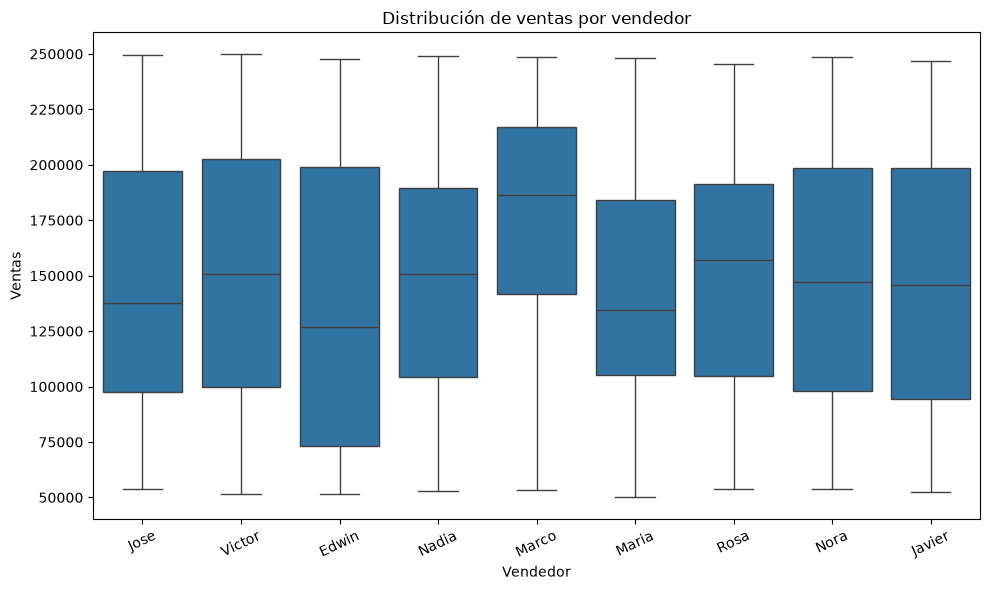

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Vendedor", y="Ventas")
plt.title("Distribución de ventas por vendedor")
plt.xlabel("Vendedor")
plt.ylabel("Ventas")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

El diagrama de caja de ventas por vendedor muestra que Marco presenta la mediana y la media más elevadas, mientras que Edwin se sitúa en la parte inferior de la distribución. Sin embargo, la mayor parte de las cajas se solapan ampliamente, lo que indica que las diferencias entre vendedores no son muy marcadas. Esta observación visual coincide con la variabilidad interna de cada grupo y sugiere que las diferencias descriptivas podrían no traducirse en diferencias estadísticamente significativas.

In [23]:
from scipy import stats

grupos_vendedores = [
    grupo["Ventas"].dropna().values
    for _, grupo in df.groupby("Vendedor")
]

resultado_anova_v = stats.f_oneway(
    *grupos_vendedores
)

print("F vendedores:", resultado_anova_v.statistic)
print("p vendedores:", resultado_anova_v.pvalue)

F vendedores: 2.45847188505489
p vendedores: 0.012266455501305108


En la comparación por vendedor, Marco presenta la mayor venta media (173.435,46) y Edwin la menor (141.391,71), mientras que el resto de vendedores se sitúa en un intervalo intermedio relativamente homogéneo. Las desviaciones típicas son similares entre vendedores, pero el diagrama de caja muestra que la mediana de Marco se sitúa claramente por encima de la del resto.

Para comprobar si estas diferencias son estadísticamente significativas, se aplicó un ANOVA de un factor sobre las ventas por vendedor. El resultado fue 𝐹=2,4585 con un valor p de 𝑝=0,0123. Dado que 𝑝<0,05, se rechaza la hipótesis nula de igualdad de medias. Por tanto, existe evidencia estadística de que al menos un vendedor presenta un rendimiento de ventas diferente al resto, destacando Marco en la parte alta de la distribución.

En conjunto, los análisis de varianza muestran un comportamiento distinto según la dimensión analizada. Por producto, las ventas medias no difieren de forma significativa 

(p=0,1526), de modo que las variaciones observadas pueden atribuirse a la variabilidad natural de las operaciones. En cambio, por vendedor sí se detectan diferencias significativas 

(p=0,0123), lo que apunta a diferencias reales en el rendimiento comercial entre los miembros del equipo.

Sección 6: evolución temporal de las ventas

In [33]:
df["Mes"] = df["Fecha"].dt.to_period("M")

ventas_mensuales = (
    df.groupby("Mes", as_index=False)
      .agg(
          Ventas=("Ventas", "sum"),
          Cantidad=("Cantidad", "sum")
      )
)

ventas_mensuales["Indice"] = range(len(ventas_mensuales))

from scipy.stats import linregress

resultado_trend = linregress(
    ventas_mensuales["Indice"],
    ventas_mensuales["Ventas"]
)

print("Pendiente:", resultado_trend.slope)
print("R:", resultado_trend.rvalue)
print("p:", resultado_trend.pvalue)

Pendiente: -1892487.6573426574
R: -0.7042347554709449
p: 0.010568527436593141


La pendiente negativa (−1,89×10'6) indica que, en promedio, las ventas mensuales disminuyen conforme avanza el tiempo.

El coeficiente de correlación R=−0.7042 refleja una relación negativa moderadamente fuerte entre el índice temporal y las ventas.

El valor p=0.0106<0.05 significa que la tendencia decreciente es estadísticamente significativa; es muy poco probable que esta caída se deba únicamente al azar. linregress() está pensado justamente para este tipo de análisis lineal con su p-value asociado.



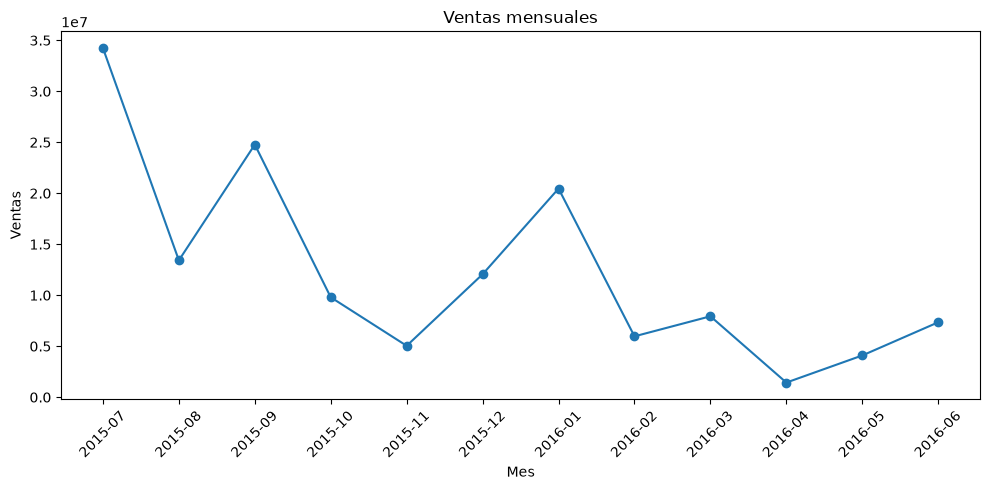

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(ventas_mensuales["Mes"].astype(str),
         ventas_mensuales["Ventas"], marker="o")
plt.xticks(rotation=45)
plt.title("Ventas mensuales")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

La evolución mensual de las ventas muestra una tendencia general descendente durante el periodo analizado. El gráfico evidencia un máximo inicial en julio de 2015 y una caída progresiva con algunos repuntes temporales en septiembre de 2015, enero de 2016 y marzo de 2016. No obstante, el comportamiento global es bajista, con un mínimo destacado en abril de 2016. Este patrón coincide con la regresión lineal obtenida, que mostró una pendiente negativa y un valor p inferior a 0,05, confirmando que la disminución de las ventas a lo largo del tiempo es estadísticamente significativa.

Sección 7: relación territorio–producto (chi-cuadrado)

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

tabla = pd.crosstab(
    df["Territorio"],
    df["Producto"]
)

chi2, pvalue, dof, esperados = chi2_contingency(tabla)

print("Chi-cuadrado:", chi2)
print("p:", pvalue)
print("Grados de libertad:", dof)

print(tabla)

Chi-cuadrado: 62.299875621058185
p: 9.526514535474045e-13
Grados de libertad: 4
Producto    Accesorios  Calzado  Electrodomesticos  Juguetes  Viajes
Territorio                                                          
Norte              140       51                 59       104      57
Sur                230       34                141       140      18


es extremadamente pequeño, se rechaza la hipótesis nula. Hay evidencia estadística muy fuerte de que el tipo de producto vendido depende del territorio, es decir, que la composición del mix de productos cambia según la zona. chi2_contingency() calcula precisamente este contraste de independencia en tablas de contingencia.